<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%206%20-%20Cameron's%20Version/regime%201/07_backprop_100M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 6 — MLP · Backprop **100M** (ceiling reference)
A ~100M deep-tanh MLP trained by Adam+MSE on the student/teacher regression. Backprop scales where the probe rule can't.

## Step 0 — Setup

In [4]:
import os, time, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device)
if device == 'cpu':
    print('WARNING: no GPU. Built for an A100 Colab runtime; set SMOKE=True to sanity-check on CPU.')

torch 2.11.0+cu128 | device: cuda


## Config (100M, backprop)

In [5]:
METHOD = 'backprop_100M'
LR_BP = 1e-3
METHOD_CFG = dict(LR_BP=LR_BP)
IN_DIM, OUT_DIM, TEACHER_HID = 64, 16, 128
HIDDEN = (7168, 7168, 7168)   # ~103M
BATCH = 256
EVAL_N, EVAL_BATCH = 4096, 1024
DRIVE_SUBDIR = 'Section6_regime1'

TIME_BUDGET_HOURS = 2.0
SEED = 0
LOG_EVERY_SEC, CKPT_EVERY_SEC, PLOT_EVERY_SEC, HEARTBEAT_EVERY_SEC = 30, 120, 1800, 60
USE_DRIVE = True
SMOKE = False
if SMOKE:
    HIDDEN=(32,); IN_DIM,OUT_DIM=16,4; TIME_BUDGET_HOURS=20/3600
    LOG_EVERY_SEC,CKPT_EVERY_SEC,PLOT_EVERY_SEC,HEARTBEAT_EVERY_SEC=1,2,999,1
    EVAL_N,EVAL_BATCH,USE_DRIVE=256,256,False

## Step 1 — Storage (Drive) + paths

In [6]:
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive')
        STORE = os.path.join('/content/drive/MyDrive', DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed -> local /content (will NOT survive disconnect):', e)
        STORE = os.path.join('/content', DRIVE_SUBDIR)
else:
    STORE = os.path.join('.', DRIVE_SUBDIR)
RESULTS_DIR = os.path.join(STORE, 'results')
CKPT_DIR    = os.path.join(STORE, 'checkpoints')
FIG_DIR     = os.path.join(STORE, 'figures')
for d in (RESULTS_DIR, CKPT_DIR, FIG_DIR): os.makedirs(d, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, f'{METHOD}.json')
CKPT_PATH    = os.path.join(CKPT_DIR,    f'{METHOD}.pt')
print('storing under:', STORE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
storing under: /content/drive/MyDrive/Section6_regime1


## Step 2 — Model

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    """Deep tanh MLP. vmap-safe (Linear + tanh only)."""
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        dims = [in_dim] + list(hidden) + [out_dim]
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
    def forward(self, x):
        for i, lyr in enumerate(self.layers):
            x = lyr(x)
            if i < len(self.layers) - 1:
                x = torch.tanh(x)
        return x

## Step 3 — Data

In [8]:
# Fixed random teacher defines the target y = teacher(x); deterministic per SEED (identical across methods).
torch.manual_seed(SEED)
teacher = nn.Sequential(nn.Linear(IN_DIM, TEACHER_HID), nn.Tanh(), nn.Linear(TEACHER_HID, OUT_DIM)).to(device)
for p in teacher.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def _teacher(x):
    return teacher(x)

Xte = torch.randn(EVAL_N, IN_DIM, device=device)
Yte = _teacher(Xte)
Yte_var = Yte.var().item()

def fresh_batch(n):
    x = torch.randn(n, IN_DIM, device=device)
    return x, _teacher(x)
print(f'teacher {IN_DIM}->{TEACHER_HID}->{OUT_DIM} | eval set {tuple(Xte.shape)} | Var(Y)={Yte_var:.4f}')

teacher 64->128->16 | eval set (4096, 64) | Var(Y)=0.0770


## Step 4 — Build (100M) + provenance

In [9]:
import math
torch.manual_seed(SEED)
model = MLP(IN_DIM, HIDDEN, OUT_DIM).to(device)
P = sum(p.numel() for p in model.parameters())
print(f'METHOD={METHOD} | student P = {P:,} (target ~100M) | in={IN_DIM} out={OUT_DIM} hidden={HIDDEN}')
CFG = dict(METHOD=METHOD, SEED=SEED, IN_DIM=IN_DIM, OUT_DIM=OUT_DIM, HIDDEN=list(HIDDEN), BATCH=BATCH, TIME_BUDGET_HOURS=TIME_BUDGET_HOURS)
CFG.update(METHOD_CFG)

METHOD=backprop_100M | student P = 103,355,408 (target ~100M) | in=64 out=16 hidden=(7168, 7168, 7168)


## Step 5 — Trainer (Adam backprop)

In [10]:
torch.manual_seed(SEED)
net = MLP(IN_DIM, HIDDEN, OUT_DIM).to(device)
opt = torch.optim.Adam(net.parameters(), lr=LR_BP)
def forward_fn(x): return net(x)
def train_step():
    xb, yb = fresh_batch(BATCH)
    opt.zero_grad(); loss = F.mse_loss(net(xb), yb); loss.backward(); opt.step()
    return loss.item()
def ckpt_state():      return {'net': net.state_dict(), 'opt': opt.state_dict()}
def load_ckpt_state(d): net.load_state_dict(d['net']); opt.load_state_dict(d['opt'])

## Step 6 — Eval / checkpoint / live-plot

In [11]:
@torch.no_grad()
def eval_metrics():
    se = 0.0; ne = 0
    for i in range(0, Xte.shape[0], EVAL_BATCH):
        pred = forward_fn(Xte[i:i+EVAL_BATCH]); yb = Yte[i:i+EVAL_BATCH]
        se += F.mse_loss(pred, yb, reduction='sum').item(); ne += yb.numel()
    mse = se / ne
    r2 = 1.0 - mse / max(Yte_var, 1e-12)      # fraction of variance explained (0..1, higher better)
    return mse, r2

In [12]:
def _atomic_save(obj, path):
    tmp = path + '.tmp'; torch.save(obj, tmp); os.replace(tmp, path)

def save_checkpoint(step, elapsed, logs):
    _atomic_save({'loop': {'step': step, 'elapsed_sec': elapsed, 'logs': logs},
                  'method': ckpt_state(), 'config': CFG}, CKPT_PATH)

def maybe_resume():
    if os.path.exists(CKPT_PATH):
        d = torch.load(CKPT_PATH, map_location=device)
        load_ckpt_state(d['method']); L = d['loop']
        print(f'[resume] {METHOD}: step {L["step"]:,}, elapsed {L["elapsed_sec"]/3600:.2f}h -> continuing.')
        return L['step'], L['elapsed_sec'], L['logs']
    return 0, 0.0, []

In [13]:
def live_plot(logs, final=False):
    if not logs: return
    hrs = [l[0]/3600 for l in logs]; tr=[l[3] for l in logs]; te=[l[4] for l in logs]; r2=[l[5] for l in logs]
    if not final: clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(hrs, tr, '-', color='#999', label='train MSE'); ax[0].plot(hrs, te, 'o-', color='#C62828', label='test MSE')
    ax[0].set_xlabel('elapsed hours'); ax[0].set_ylabel('MSE'); ax[0].set_yscale('log')
    ax[0].set_title(f'{METHOD}: MSE vs time'); ax[0].legend()
    ax[1].plot(hrs, r2, 'o-', color='#1F3864'); ax[1].set_xlabel('elapsed hours'); ax[1].set_ylabel('R^2'); ax[1].set_title('R^2 vs time')
    plt.tight_layout()
    try: fig.savefig(os.path.join(FIG_DIR, f'{METHOD}_progress.png'), dpi=90)
    except Exception as e: print('savefig failed:', e)
    plt.show()
    last = logs[-1]; print(f'[h={last[0]/3600:.2f}] step={last[1]:,} test_mse={last[4]:.5f} R2={last[5]:.3f}')

## Step 7 — Train (equal wall-clock, heartbeat) + save results

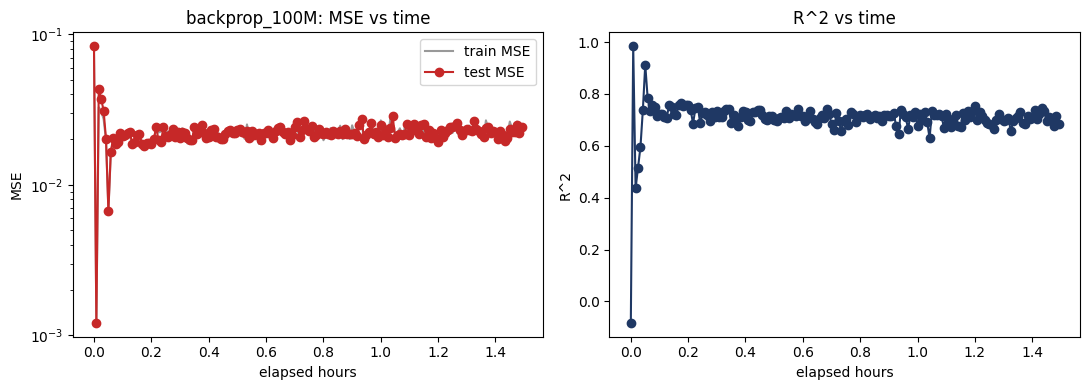

[h=1.49] step=666,231 test_mse=0.02436 R2=0.684
[backprop_100M] h=1.50 step=669,780 train=0.02349 test_mse=0.02436 R2=0.684
[backprop_100M] h=1.52 step=677,292 train=0.02305 test_mse=0.02171 R2=0.718
[backprop_100M] h=1.53 step=684,665 train=0.02477 test_mse=0.02339 R2=0.696
[backprop_100M] h=1.55 step=692,183 train=0.02406 test_mse=0.02442 R2=0.683
[backprop_100M] h=1.57 step=699,563 train=0.02136 test_mse=0.02056 R2=0.733
[backprop_100M] h=1.58 step=707,077 train=0.02270 test_mse=0.02065 R2=0.732
[backprop_100M] h=1.60 step=714,456 train=0.02107 test_mse=0.02404 R2=0.688
[backprop_100M] h=1.62 step=721,974 train=0.01970 test_mse=0.02139 R2=0.722
[backprop_100M] h=1.63 step=729,344 train=0.02268 test_mse=0.02288 R2=0.703
[backprop_100M] h=1.65 step=736,861 train=0.02343 test_mse=0.02369 R2=0.692
[backprop_100M] h=1.67 step=744,238 train=0.02134 test_mse=0.02230 R2=0.710
[backprop_100M] h=1.68 step=751,752 train=0.02538 test_mse=0.02483 R2=0.678
[backprop_100M] h=1.70 step=759,118 trai

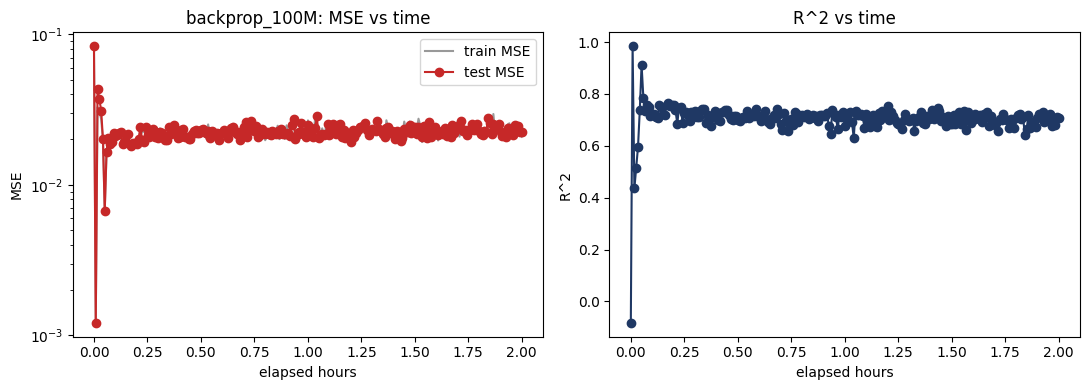

[h=2.00] step=893,022 test_mse=0.02259 R2=0.707
wrote /content/drive/MyDrive/Section6_regime1/results/backprop_100M.json
DONE backprop_100M: 893,022 steps, 2.00h, final R2 0.707, best MSE 0.00121


In [14]:
def write_results(step, elapsed, logs):
    te = [l[4] for l in logs]; r2 = [l[5] for l in logs]
    summary = dict(initial_mse=logs[0][4], final_mse=logs[-1][4], best_mse=min(te),
                   reduction_pct=100*(logs[0][4]-min(te))/max(logs[0][4], 1e-12),
                   final_r2=logs[-1][5], best_r2=max(r2))
    peak = torch.cuda.max_memory_allocated()/1e6 if device == 'cuda' else float('nan')
    out = dict(meta=dict(method=METHOD, device=device, seed=SEED, P=P, config=CFG, note='all MEASURED-here',
                         wall_clock_sec=elapsed, total_steps=step, samples=step*BATCH, peak_mem_mb=peak),
               curve=dict(t_sec=[l[0] for l in logs], step=[l[1] for l in logs], samples=[l[2] for l in logs],
                          train_mse=[l[3] for l in logs], test_mse=te, test_r2=r2),
               summary=summary)
    with open(RESULTS_PATH, 'w') as f: json.dump(out, f, indent=2)
    print('wrote', RESULTS_PATH)

def run():
    step, elapsed0, logs = maybe_resume()
    t0 = time.time(); budget = TIME_BUDGET_HOURS*3600
    last_ckpt = last_plot = last_log = last_beat = elapsed0
    if not logs:
        m0, a0 = eval_metrics(); logs.append((elapsed0, step, 0, m0, m0, a0))
    tl = logs[-1][3]; printed = False
    while True:
        elapsed = elapsed0 + (time.time() - t0)
        if elapsed >= budget: break
        tl = train_step(); step += 1
        if not printed:
            dt = time.time() - t0
            print(f'[{METHOD}] step 1 = {dt:.2f}s -> ~{int(budget/max(dt,1e-9)):,} steps fit the budget.', flush=True); printed = True
        if elapsed - last_log >= LOG_EVERY_SEC:
            mse, r2 = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, r2)); last_log = elapsed
        if elapsed - last_beat >= HEARTBEAT_EVERY_SEC:
            L = logs[-1]
            print(f'[{METHOD}] h={elapsed/3600:.2f} step={step:,} train={L[3]:.5f} test_mse={L[4]:.5f} R2={L[5]:.3f}', flush=True)
            last_beat = elapsed
        if elapsed - last_ckpt >= CKPT_EVERY_SEC:
            save_checkpoint(step, elapsed, logs); last_ckpt = elapsed
        if elapsed - last_plot >= PLOT_EVERY_SEC:
            live_plot(logs); last_plot = elapsed
    elapsed = elapsed0 + (time.time() - t0)
    mse, r2 = eval_metrics(); logs.append((elapsed, step, step*BATCH, tl, mse, r2))
    save_checkpoint(step, elapsed, logs); live_plot(logs, final=True); write_results(step, elapsed, logs)
    print(f'DONE {METHOD}: {step:,} steps, {elapsed/3600:.2f}h, final R2 {r2:.3f}, best MSE {min(l[4] for l in logs):.5f}')

run()

## How to run
- `SMOKE=True` first (~30 s tiny model), then `False` → Runtime → Run all on an A100.
- Backprop can train 100M fine (the probe rule can't — cost ~P²), so this is the **ceiling** reference. Same equal-wall-clock harness: heartbeat, Drive checkpoint/auto-resume, live plot, `results/backprop_100M.json`.
- Reduce `BATCH` if you hit CUDA OOM.